# Object Detection with Faster R-CNN

**Author:** Alexander Michels

This notebook will work through object detection within Street View Imagery using a pre-trained Faster R-CNN model. The last notebook discussed how a computer stores imagery and the pitfalls of simplistic pixel-based approaches. Here, we introduce some of the machine learning and artificial intelligence (AI) concepts used for detecting objects within imagery.

## Overview of Computer Vision

Computer vision (CV) is the field within AI that aims to understand visual data like images. The next notebook will explore generative AI, but this notebook focuses more on traditional computer vision tasks. Traditional CV work focused on tasks like:

* **Classification:** classifying an image into a category. For example: is this a picture of a cat or a dog?
* **Classification and Localization:** classifying an image into a category and providing a bounding box around the object you are classifying. For example: does this image contain a cat or dog and where in the image is it?
* **Object Detection:** detecting individual objects within an image and providing a bounding box around those objects. For example, where in this image are all of the dogs and cats?
* **Semantic Segmentation:** classifying pixels within the image into categories like "cat" and "sky".
* **Instance Segmentation:** classifying objects at the pixel level. For example, what pixels in this image make up individual cats and dogs?

The image below provides some examples of these CV tasks.

![An explanation of common computer vision tasks](img/Computer-Vision.png)

*Image credits: https://indatalabs.com/blog/how-does-computer-vision-work*

In this notebook, we will demonstrate how to use pre-trained object detection models from torchvision to analyze street view imagery. Specifically, we will be working with the Faster R-CNN model. Convolutional Neural Networks (CNNs) are a type of Neural Network, a machine learning technique that uses layers of artificial neurons networked together. Data travels through the network using connections between the neurons and we "train" these models by adjusting how the data flows through it. A convolutional neural network (CNN) uses convolution kernels (a similar concept to kernel density estimation or kernel-based smoothing) to try to understand the features within the image rather than analyzing each pixel independently. The math of CNNs are a bit beyond this notebook, but there are many excellent visualizations and explainers for those curious:

* [Adam Harley's 3D visualizer](https://adamharley.com/nn_vis/cnn/3d.html)
* [Georgia Tech's CNN Explainer](https://poloclub.github.io/cnn-explainer/)

We will start by importing the required packages:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from torchvision.io import decode_image, read_file
import torchvision.transforms.functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_bounding_boxes

Next, we will create a quick helper function that will display a list of images together. This will make it easier to see the street view imagery we are working with.

In [2]:
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    _height = 6
    fig, axs = plt.subplots(figsize=(_height*len(imgs), _height), ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

We will also use the torch `decode_image` function that will help us automatically load images in a format that the model expects. You can see from the output though that this is very similar to what we did in the last notebook, we just have arrays of pixels with values from 0-255 giving the intensity of the Red, Green, and Blue for each image.

In [3]:
decode_image(read_file("data/kaggle-samples/0.png"))

tensor([[[184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         ...,
         [117, 106, 123,  ...,  64,  51,  55],
         [109,  85, 125,  ...,  50,  55,  48],
         [ 97, 137, 130,  ...,  45,  48,  62]],

        [[184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         ...,
         [113, 102, 119,  ...,  63,  50,  54],
         [103,  79, 119,  ...,  49,  54,  47],
         [ 91, 131, 124,  ...,  44,  47,  61]],

        [[184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         ...,
         [114, 103, 120,  ...,  61,  48,  52],
         [105,  81, 121,  ...,  47,  52,  45],
         [ 93, 133, 126,  ...,  42,  45,  59]]], dtype=torch.uint8)

We will use a few different images for this notebook to see how well the model can detect different images and in different contexts. Let's create a list of images and then display it:

In [4]:
image_list = [
    decode_image(read_file(f"data/kaggle-samples/{x}.png")) for x in [2, 18, 255]
]

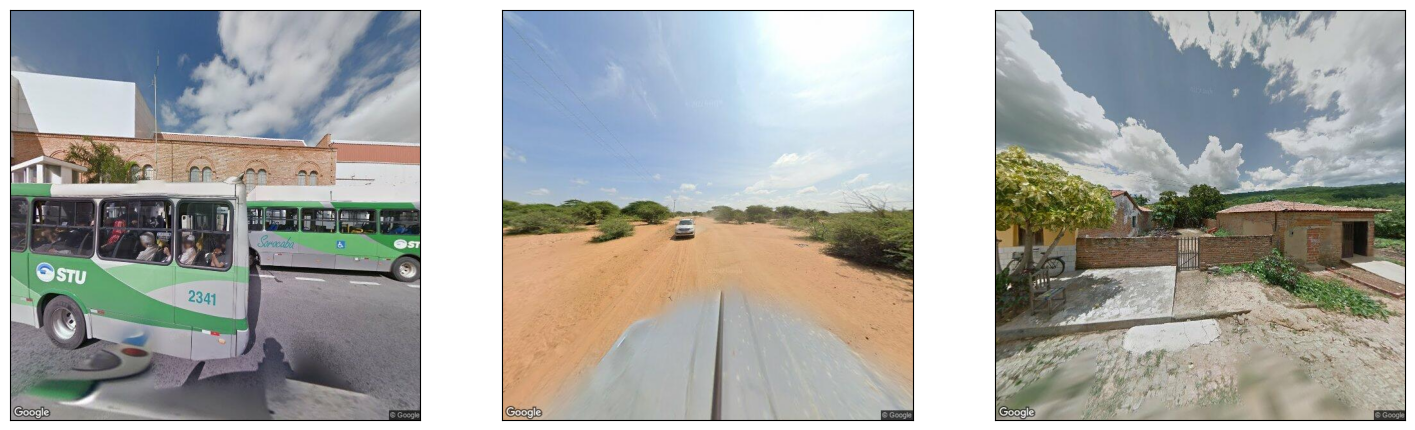

In [5]:
show(image_list)

Luckily, we can use a pre-trained model so we won't have to do all of the work ourselves! We can load the pre-trained weights using the following line of code and receive a `transforms` function we can apply to regular images to pre-process them for our model.

More documentation on the torchvision weights can be found here: https://docs.pytorch.org/vision/main/models.html#table-of-all-available-object-detection-weights

In [6]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
transforms = weights.transforms()

Our [weights object](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn.html#torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights) has some metadata including the categories of objects it can detect. Let's see how many categories we can detect and then print the list:

In [7]:
len(weights.meta["categories"])

91

In [8]:
weights.meta["categories"]

['__background__',
 'person',
 'bicycle',
 'car',
 'motorcycle',
 'airplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'N/A',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'N/A',
 'backpack',
 'umbrella',
 'N/A',
 'N/A',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'N/A',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'couch',
 'potted plant',
 'bed',
 'N/A',
 'dining table',
 'N/A',
 'N/A',
 'toilet',
 'N/A',
 'tv',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'N/A',
 'book',
 'clock',
 'vase',
 'scissors',
 'ted

We will use the model with pre-trained weights. [Documentation on that model can be found here](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn.html).

We will pass the model our weights and `progress=False` just means we won't show a progress bar of the download. We then set the model to inference mode meaning we want to use the model instead of train it!

In [9]:
model = fasterrcnn_resnet50_fpn(weights=weights, progress=False)
model = model.eval()

Then, we apply the transforms function associated with our model and weights to ensure the image data is pre-processed. This performs steps like scaling the pixels from 0-255 to 0-1, a bit more information is available on the [documentation page for the weights](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn.html#torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights).

Once transformed, we can give the model our list of images and get the outputs!

In [10]:
images = [transforms(d) for d in image_list]
outputs = model(images)
outputs

[{'boxes': tensor([[370.7751, 282.3817, 640.0000, 419.0782],
          [  3.5643, 264.6360, 408.8775, 541.0180],
          [262.0772, 352.6993, 291.4592, 397.7032],
          [194.2547, 347.8468, 241.5027, 393.4224],
          [310.2563, 361.6261, 337.2448, 402.2215],
          [142.2792, 320.8899, 182.8963, 377.8744],
          [282.7533, 357.8289, 312.6397, 400.0706],
          [398.0951, 328.7790, 418.0642, 345.1296],
          [172.9819, 502.3378, 216.5121, 526.6054],
          [315.1974, 353.9208, 339.7855, 389.7536],
          [ 90.4433, 319.2050, 183.2062, 377.3288],
          [397.5656, 329.0843, 407.7492, 345.1355],
          [271.3117, 355.6964, 331.6042, 402.0404],
          [ 36.9500, 341.9146,  87.5235, 380.1817],
          [227.2215, 313.6038, 241.2255, 341.6263],
          [204.8827, 349.0009, 271.9507, 396.3867],
          [548.1051, 331.5201, 560.4835, 347.2223],
          [371.5222, 369.5980, 389.6468, 406.9739],
          [104.7047, 315.6453, 152.3463, 383.4993],
   

That outputs a lot of data! The next cell helps us make a bit more sense of it!

We see the length of the outputs is 3, one for each image we passed in. Each image has a dictionary of "boxes", "labels", and "scores". 

* "boxes" are the bounding boxes around the objects.
* "labels" tells us which category is detected. A label of 2 means the second category in our list of categories if we start counting at 0. In our case the list is "__background__", "person", "bicycle"... with "bicycle" being index 2.
* "scores" are the confidence of the prediction. We got a LOT of predictions, but we will only use the ones that model has high confidence in. We will use 80%, but the exact number depends on your model, task, etc.

In [11]:
print(len(outputs))
print(outputs[0].keys())

3
dict_keys(['boxes', 'labels', 'scores'])


Let's draw our images and the bounding boxes that have at least 80% confidence. torchvision has a very convenient `draw_bounding_boxes` function we can use!

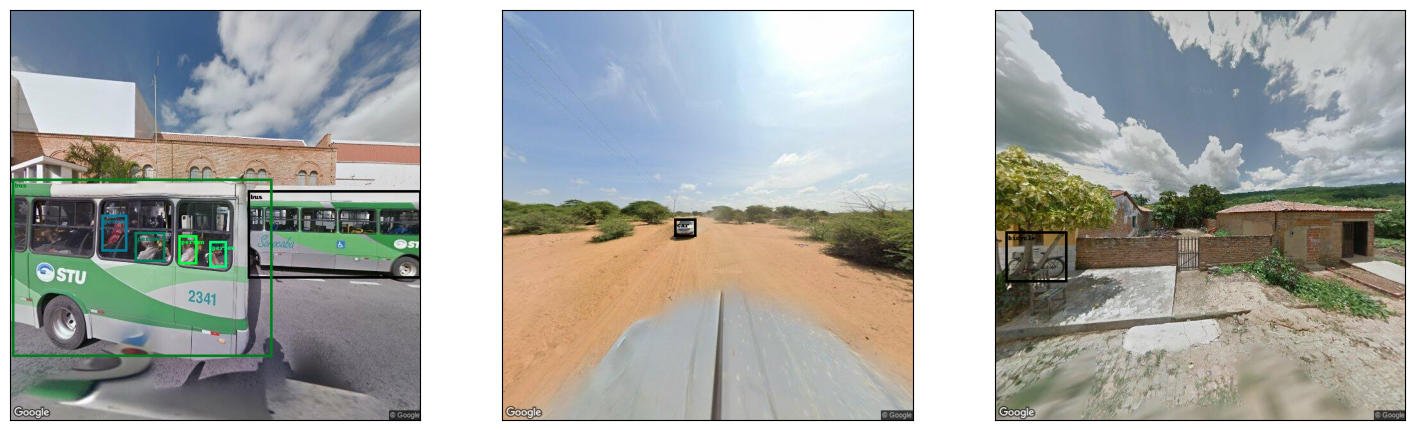

In [12]:
score_threshold = .8
imgs_with_boxes = []
for img_int, output in zip(image_list, outputs):
    imgs_with_boxes.append(draw_bounding_boxes(img_int, boxes=output['boxes'][output['scores'] > score_threshold], width=4, 
                        labels=[weights.meta["categories"][_label] for _label in output['labels'][output['scores'] > score_threshold]]))
show(imgs_with_boxes)

The labels are a bit hard to see, so let's print some of the labels from the first image (index 0):

In [13]:
output = outputs[0]
for _lable in output['labels'][output['scores'] > score_threshold]:
    print(weights.meta["categories"][_lable])

bus
bus
person
person
person
person


Let's combine the above code into a single function where we can provide an image and model to display the image and get the labels.

In [14]:
def obj_detect(image, model, score_threshold=0.8):
    """
    Function that combines a few of the above steps to
    quickly and easily run the object detection model and
    visualize the outputs.
    """
    outputs = model([transforms(image)])
    output = outputs[0]
    labels = [weights.meta["categories"][_label] for _label in output['labels'][output['scores'] > score_threshold]]
    img_with_boxes = draw_bounding_boxes(image, boxes=output['boxes'][output['scores'] > score_threshold], labels=labels, width=4)
    show(img_with_boxes)
    return labels
    

## Street View Imagery

Let's briefly see how we can apply this to our some of our own street view imagery (SVI). Street view imagery, sometimes called street-level imagery, is an image taken from pedestrian-level and usually from a vehicle or person on the street. This is opposed to aerial imagery like drones or satellite imagery that provides the top-down perspective. This type of imagery is very popular in large part due to Google Street View and very useful for understanding how a person perceives space.

[Learn more about street-view imagery here](https://gistbok-topics.ucgis.org/DC-02-011)

![An image showing the difference between aerial perspective and street-level imagery](img/SVIBiljecki.jpg)

*Image Credits, but also a great paper to read!: https://doi.org/10.1016/j.landurbplan.2021.104217*

While Google has amazing data, [they have very restrictive terms of service](https://about.google/brand-resource-center/products-and-services/geo-guidelines/#street-view) so use this data at your own peril! However, there are other more open sources of street view imagery including Mapillary! All of these images are shared under [CC BY-SA](https://creativecommons.org/licenses/by-sa/4.0/) and you can check out some of their compiled datasets here: https://www.mapillary.com/datasets

For this example, I grabbed an image from the University of Texas at Dallas: https://www.mapillary.com/app/?pKey=561334792755861 (thanks to directionup for sharing!). By pulling up the image, clicking the "..." and then hitting "Download Image" you can download imagery yourself. If you want to follow along, feel free to find your own SV image and use our model on it!

![Mapillary download link](img/Mapillary.png)

The image can be viewed below:



<iframe width="640" height="480" src="https://www.mapillary.com/embed?map_style=Mapillary%20light&image_key=561334792755861&x=0.49999999999999933&y=0.5&style=photo" frameborder="0"></iframe>

Here, I'm going to load the image. If you have your own image to use, you can replace "data/UTD.jpeg" with the path to your image! If you upload your image into the same folder as this notebook, the path is just the filename (including the file extension like ".png" or ".jpeg").

In [15]:
UTD_image = decode_image(read_file(f"data/UTD.jpeg"))
UTD_image

tensor([[[ 73,  87, 131,  ..., 253, 253, 253],
         [ 64,  79, 126,  ..., 253, 253, 253],
         [ 87,  88, 103,  ..., 254, 254, 254],
         ...,
         [116, 115, 116,  ...,  94,  96,  98],
         [117, 115, 116,  ...,  94,  97,  99],
         [117, 114, 115,  ...,  94,  97, 100]],

        [[ 70,  84, 128,  ..., 254, 254, 254],
         [ 61,  76, 123,  ..., 254, 254, 254],
         [ 84,  85, 100,  ..., 255, 255, 255],
         ...,
         [118, 117, 118,  ...,  95,  97,  99],
         [119, 117, 118,  ...,  95,  98, 100],
         [119, 116, 117,  ...,  95,  98, 101]],

        [[ 65,  79, 123,  ..., 249, 249, 249],
         [ 56,  71, 118,  ..., 249, 249, 249],
         [ 79,  80,  95,  ..., 250, 250, 250],
         ...,
         [115, 114, 115,  ...,  97,  99, 101],
         [116, 114, 115,  ...,  97, 100, 102],
         [116, 113, 114,  ...,  97, 100, 103]]], dtype=torch.uint8)

Then, we can use our `obj_detect` function on our image:

['stop sign', 'car', 'car']

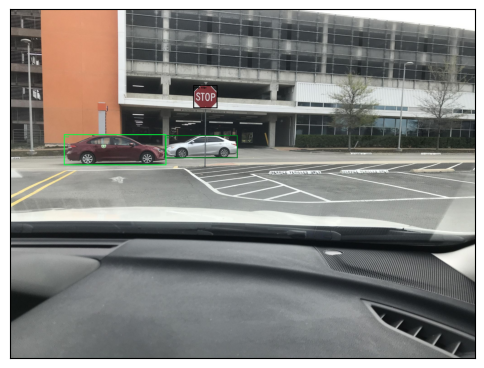

In [16]:
obj_detect(UTD_image, model)